In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

In [4]:
diabetes = load_diabetes()

X = diabetes.data
y = diabetes.target

df = pd.DataFrame(X, columns=diabetes.feature_names)
df['target'] = y

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [19]:
print(df.shape)
df.info()
df.describe()

(442, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          442 non-null    float64
 1   sex          442 non-null    float64
 2   bmi          442 non-null    float64
 3   bp           442 non-null    float64
 4   s1           442 non-null    float64
 5   s2           442 non-null    float64
 6   s3           442 non-null    float64
 7   s4           442 non-null    float64
 8   s5           442 non-null    float64
 9   s6           442 non-null    float64
 10  target       442 non-null    float64
 11  bmi_bp       442 non-null    float64
 12  bmi_squared  442 non-null    float64
 13  risk_index   442 non-null    float64
dtypes: float64(14)
memory usage: 48.5 KB


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target,bmi_bp,bmi_squared,risk_index
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000,442.000000,4.420000e+02,4.420000e+02
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484,0.000895,2.262443e-03,-1.788414e-16
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005,0.002406,3.267015e-03,1.113725e-01
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000,-0.007558,6.807836e-08,-2.264696e-01
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000,-0.000247,2.530092e-04,-8.301763e-02
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000,0.000344,1.133877e-03,-8.082645e-03
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000,0.001681,3.217685e-03,7.641863e-02
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000,0.012440,2.908909e-02,2.726249e-01


target distribution

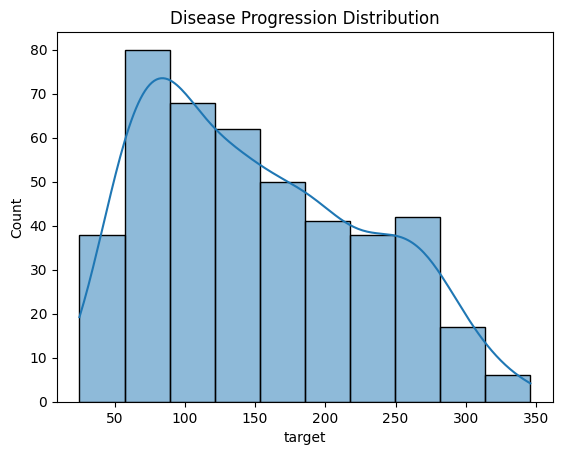

In [7]:
sns.histplot(df['target'], kde=True)
plt.title("Disease Progression Distribution")
plt.show()

correlation heatmap

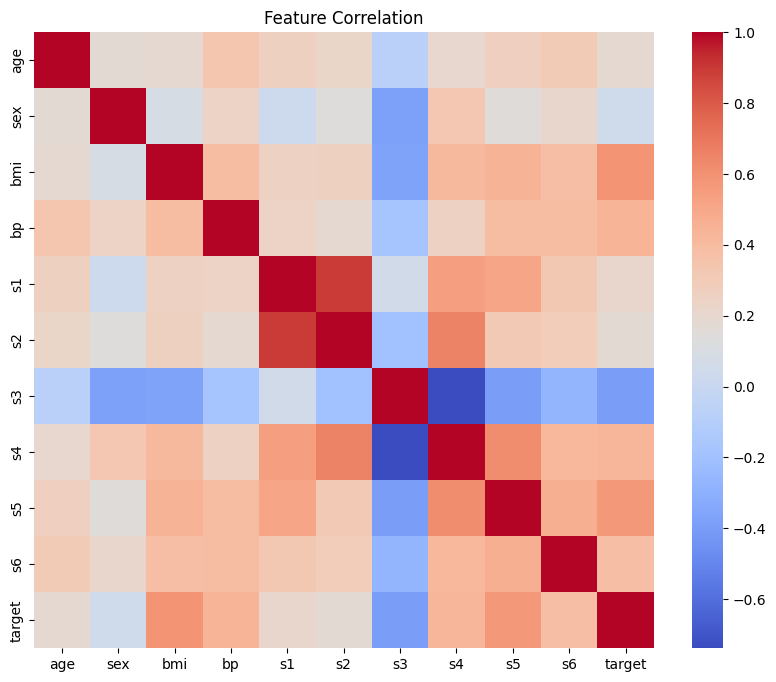

In [8]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

FEATURE ENGINEERING

1.Interaction Feature

In [9]:
df['bmi_bp'] = df['bmi'] * df['bp']

2.polynomial

In [10]:
df['bmi_squared'] = df['bmi'] ** 2

3.risk index

In [11]:
df['risk_index'] = df['bmi'] + df['bp'] + df['s5']

Feature Target split

In [ ]:
X = df.drop('target', axis=1)
y = df['target']

Feature Scaling

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Train–Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

Model Building (Prediction)

In [14]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score

# 1. Linear Regression
# Simple baseline model assuming linear relationship
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Linear Regression R2:", r2_score(y_test, y_pred_lr))


# 2. Ridge Regression
# Adds L2 regularization to reduce overfitting
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
print("Ridge Regression R2:", r2_score(y_test, y_pred_ridge))


# 3. Lasso Regression
# Adds L1 regularization and performs feature selection
lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)
print("Lasso Regression R2:", r2_score(y_test, y_pred_lasso))

Linear Regression R2: 0.4526027629719196
Ridge Regression R2: 0.45414358564016677
Lasso Regression R2: 0.4529486842252207


Advanced Machine Learning Models

In [16]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score

# 1. Random Forest Regressor
# Ensemble of decision trees using bagging
# Captures nonlinear relationships
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest R2:", r2_score(y_test, y_pred_rf))


# 2. Gradient Boosting Regressor (Best Model)
# Sequential ensemble model that corrects previous errors
gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)
print("Gradient Boosting R2:", r2_score(y_test, y_pred_gbr))


# 3. Support Vector Regressor (SVR)
# Kernel-based model suitable for complex nonlinear patterns
svr = SVR(kernel='rbf')
svr.fit(X_train, y_train)
y_pred_svr = svr.predict(X_test)
print("SVR R2:", r2_score(y_test, y_pred_svr))

Random Forest R2: 0.4258777827037806
Gradient Boosting R2: 0.4591793896141524
SVR R2: 0.18211365770500298


Model Evaluation Function

In [17]:
def evaluate(y_true, y_pred):
    print("MAE :", mean_absolute_error(y_true, y_pred))
    print("MSE :", mean_squared_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2  :", r2_score(y_true, y_pred))

In [18]:
evaluate(y_test, y_pred_gbr)

MAE : 43.75697913052903
MSE : 2865.349662549594
RMSE: 53.52896097020373
R2  : 0.4591793896141524
